# Cinema Analytics

This notebook analyzes IMDB movie data to gain insights into movie revenues, ratings, and other metrics.

## Overview
- Load and explore the dataset
- Clean and preprocess the data
- Perform exploratory data analysis with visualizations
- Analyze trends in revenue, ratings, and genres

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Exploration

In [7]:
df = pd.read_csv("1/IMDB-Movie-Data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 12)


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [8]:
df.info()
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB

Columns: ['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', '

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

## Data Cleaning

In [9]:
drop_columns = ['Rank', 'Description', 'Votes', 'Metascore']
df.drop(columns=drop_columns, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("Shape after cleaning:", df.shape)
print("Remaining missing values:")
df.isnull().sum()

Shape after cleaning: (872, 8)
Remaining missing values:


Title                 0
Genre                 0
Director              0
Actors                0
Year                  0
Runtime (Minutes)     0
Rating                0
Revenue (Millions)    0
dtype: int64

In [10]:
df['Revenue(INR)'] = df['Revenue (Millions)'] * 82
print("New column added: Revenue(INR)")
df.head()

New column added: Revenue(INR)


,Title,Genre,Director,Actors,Year,Runtime (Minutes),Rating,Revenue (Millions),Revenue(INR)
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,333.13,27316.66
1,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,126.46,10369.72
2,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,138.12,11325.84
3,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,270.32,22166.24
4,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,325.02,26651.64


In [11]:
df = df[df['Revenue (Millions)'] > 0]
print("Shape after removing invalid revenues:", df.shape)

Shape after removing invalid revenues: (871, 9)


In [ ]:
def categorize_engagement(rating):
    if rating > 7.5:
        return 'High'
    elif rating >= 4.5:
        return 'Medium'
    else:
        return 'Low'

df['Engagement_Tier'] = df['Rating'].apply(categorize_engagement)

,Title,Genre,Director,Actors,Year,Runtime (Minutes),Rating,Revenue (Millions),Revenue(INR),Engagement_Tier
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,333.13,27316.66,High
1,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,126.46,10369.72,Medium
2,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,138.12,11325.84,Medium
3,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,270.32,22166.24,Medium
4,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,325.02,26651.64,Medium
...,...,...,...,...,...,...,...,...,...,...
993,Resident Evil: Afterlife,"Action,Adventure,Horror",Paul W.S. Anderson,"Milla Jovovich, Ali Larter, Wentworth Miller,K...",2010,97,5.9,60.13,4930.66,Medium
994,Project X,Comedy,Nima Nourizadeh,"Thomas Mann, Oliver Cooper, Jonathan Daniel Br...",2012,88,6.7,54.72,4487.04,Medium
996,Hostel: Part II,Horror,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,17.54,1438.28,Medium
997,Step Up 2: The Streets,"Drama,Music,Romance",Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,58.01,4756.82,Medium


## Exploratory Data Analysis

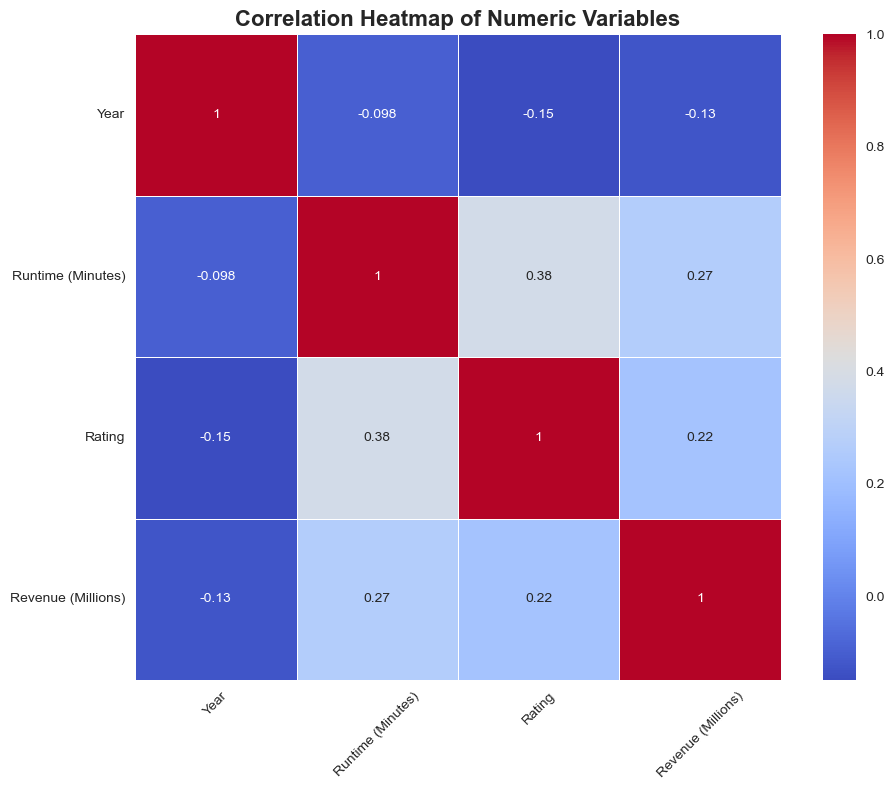

In [12]:
numeric_cols = ['Year', 'Runtime (Minutes)', 'Rating', 'Revenue (Millions)']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
df['Engagement_Tier'].value_counts()

Engagement_Tier
Medium    676
High      185
Low        10
Name: count, dtype: int64

In [13]:
df_year = df.groupby('Year')['Revenue(INR)'].mean()
print("Average Revenue (INR) by Year:")
df_year

Average Revenue (INR) by Year:


Year
2006    7076.326667
2007    7206.344082
2008    8124.785098
2009    9233.304681
2010    8616.689474
2011    7184.205161
2012    8853.809063
2013    7143.989091
2014    6976.455319
2015    6425.113628
2016    4506.643627
Name: Revenue(INR), dtype: float64

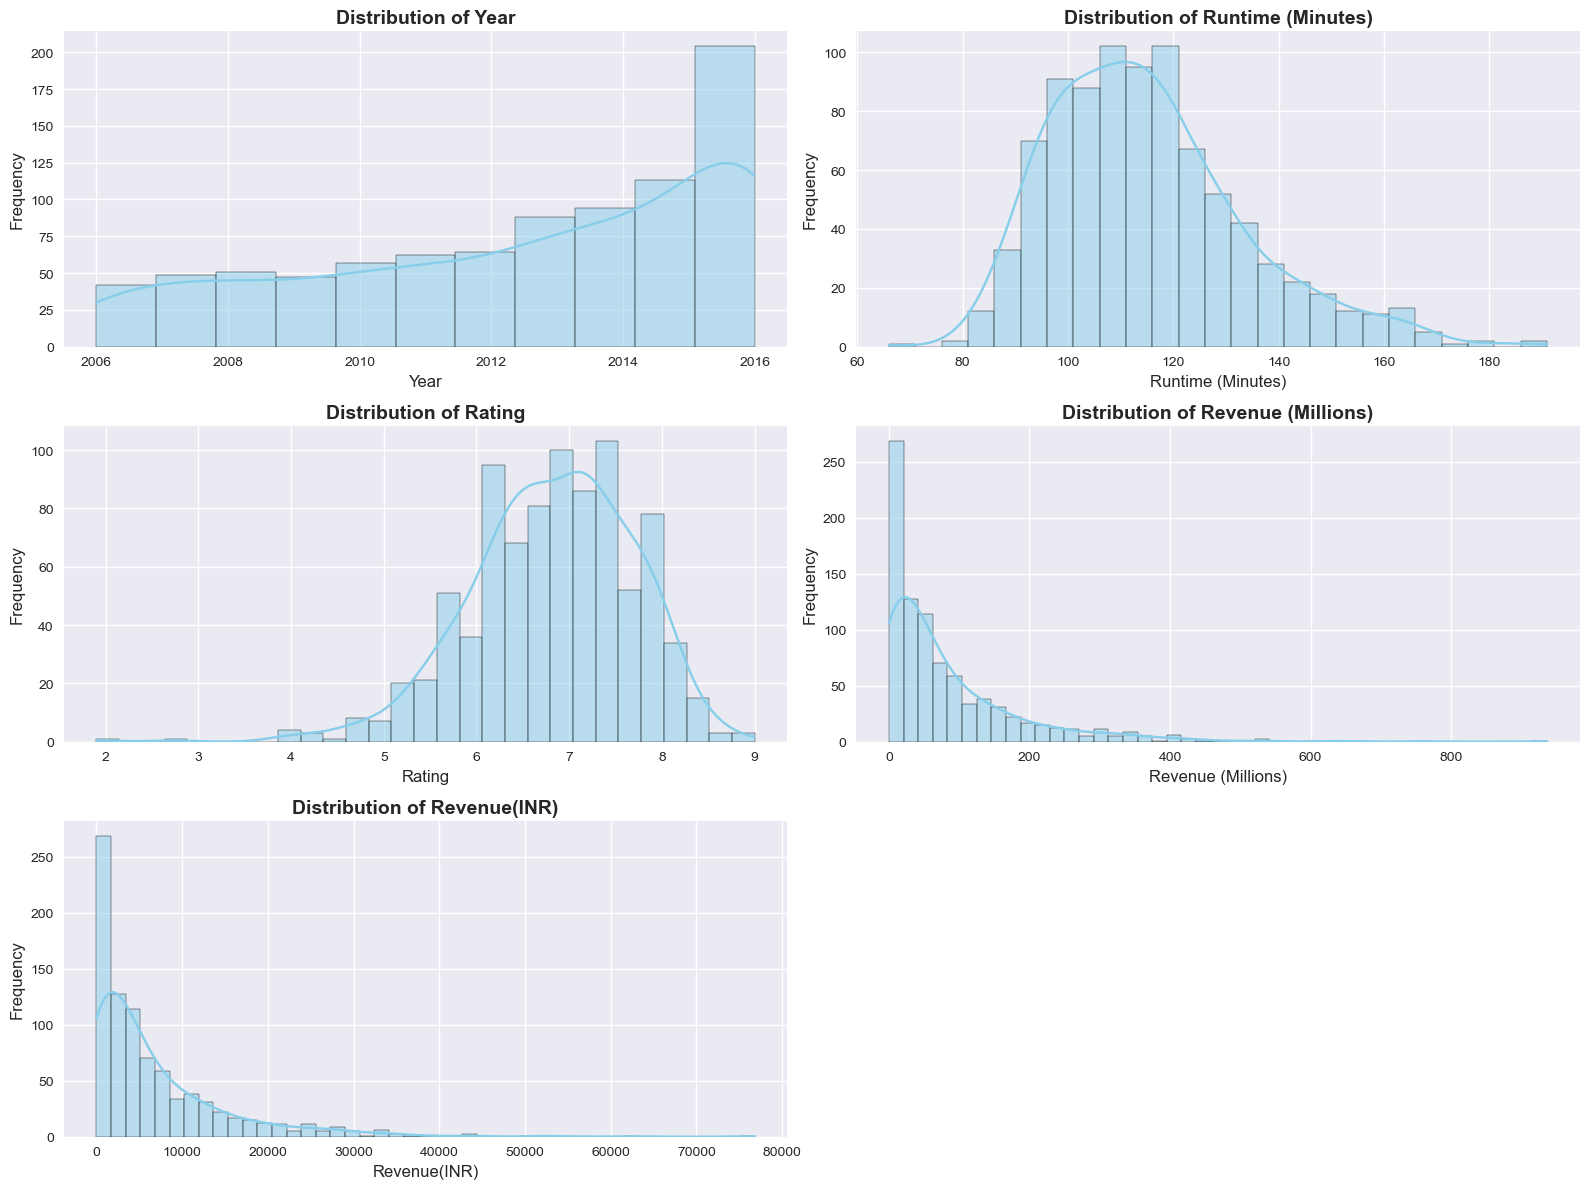

In [47]:
features = ['Year', 'Runtime (Minutes)', 'Rating', 'Revenue (Millions)', 'Revenue(INR)']
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[feature],kde=True,color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

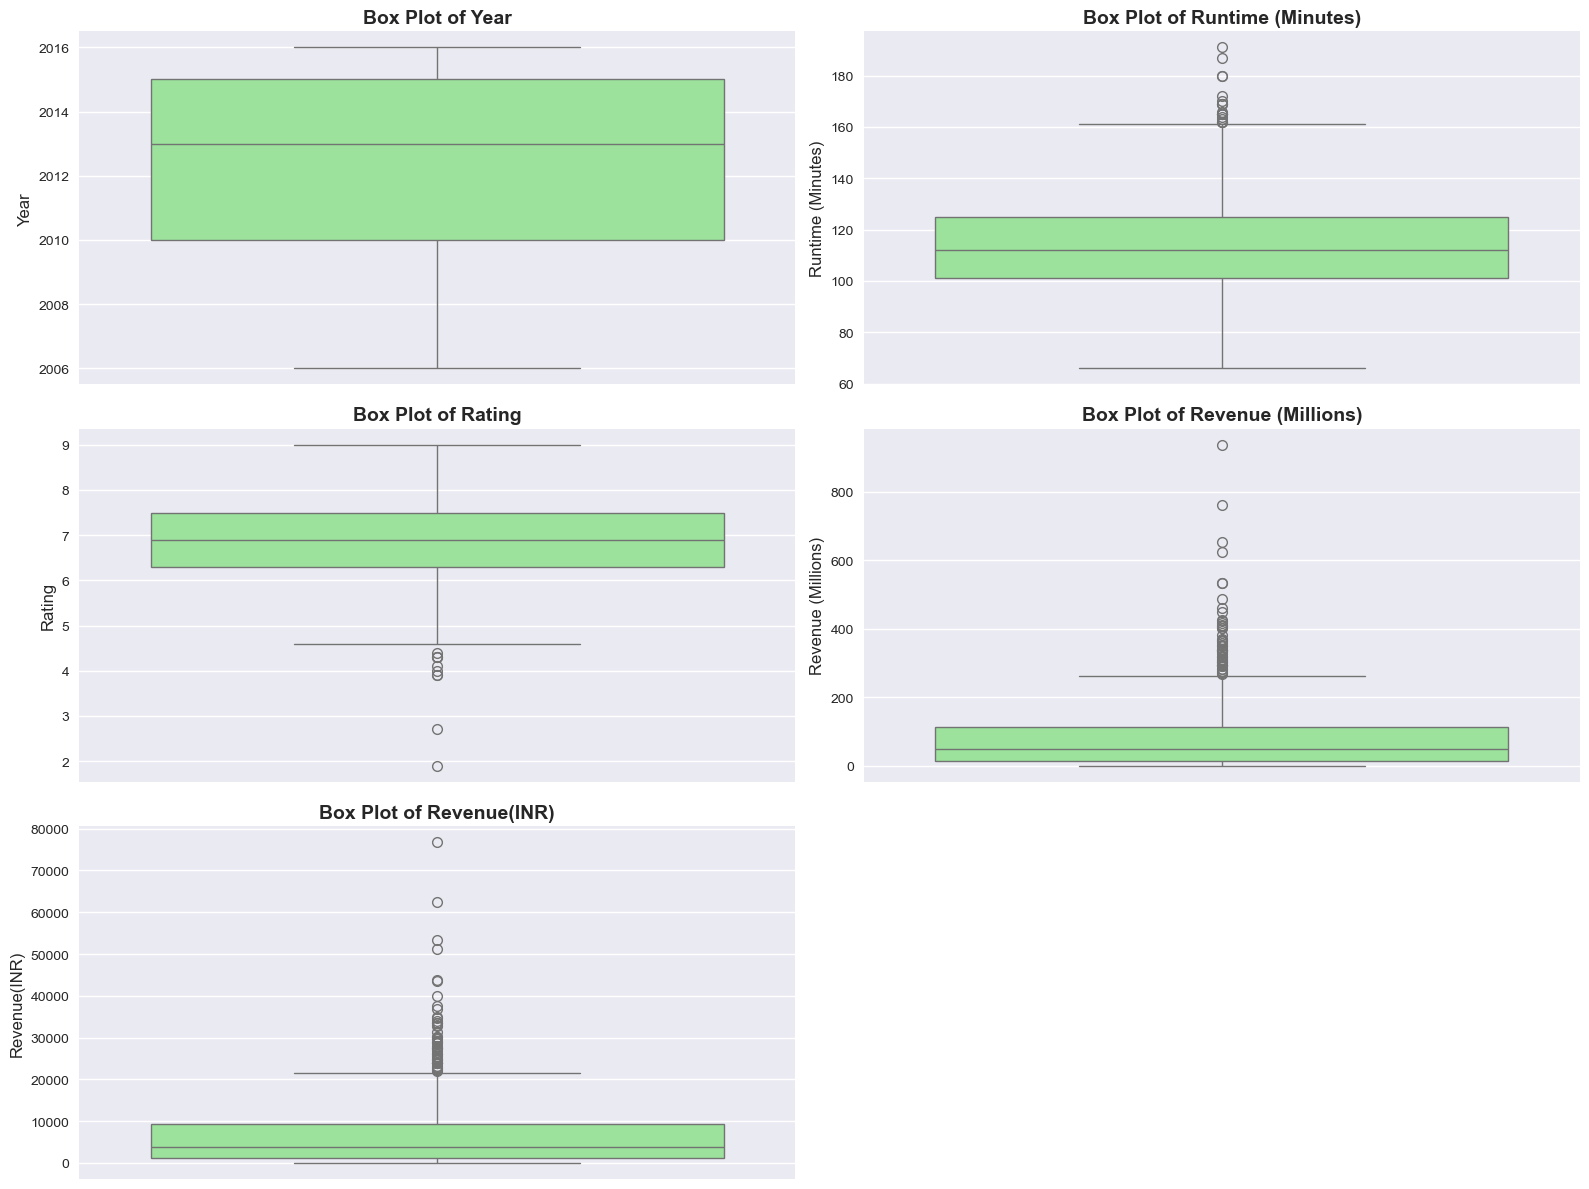

In [15]:
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features):
    plt.subplot(3, 2, i+1)
    sns.boxplot(y=df[feature], color='lightgreen')
    plt.title(f'Box Plot of {feature}', fontsize=14, fontweight='bold')
    plt.ylabel(feature, fontsize=12)
plt.tight_layout()
plt.show()

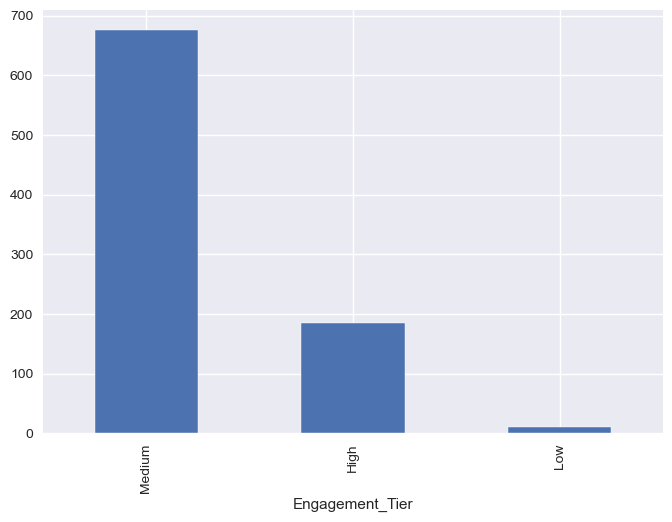

In [ ]:
plt.figure(figsize=(8,10))
df['Engagement_Tier'].value_counts().plot(kind='bar')
plt.show()

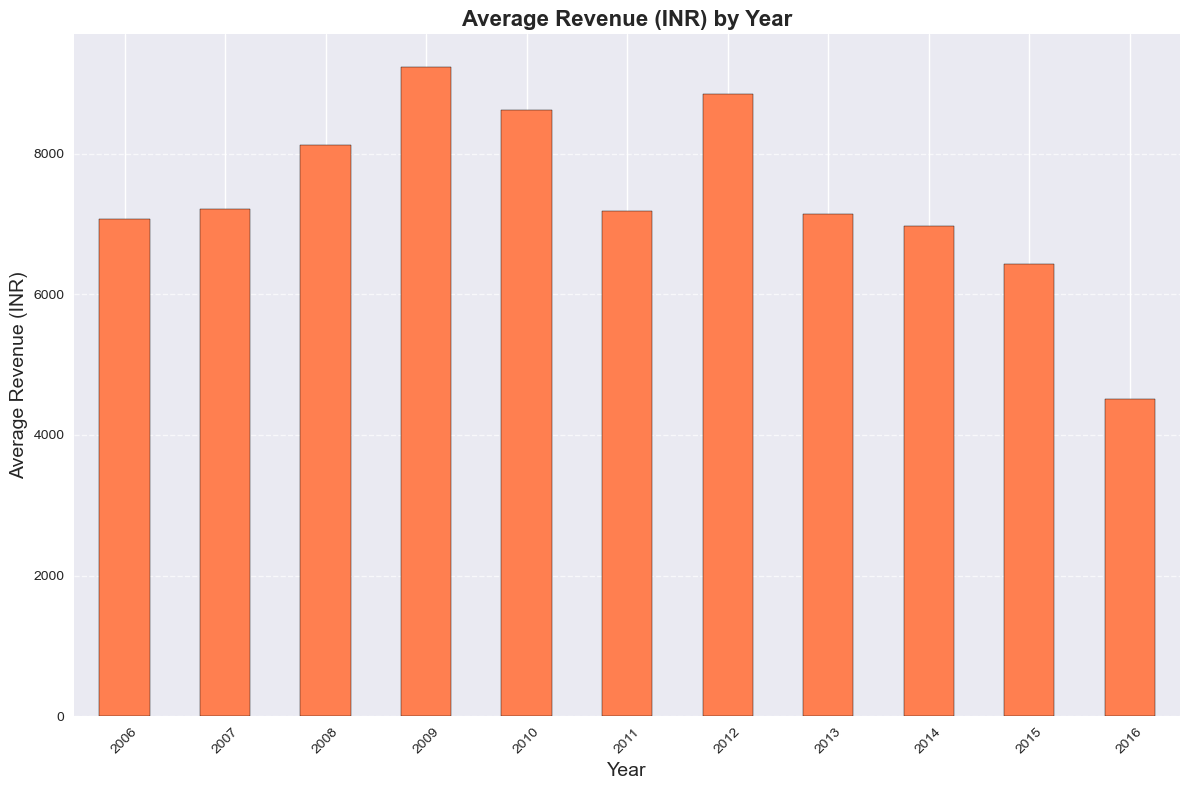

In [16]:
plt.figure(figsize=(12, 8))
df_year.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Revenue (INR) by Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Revenue (INR)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

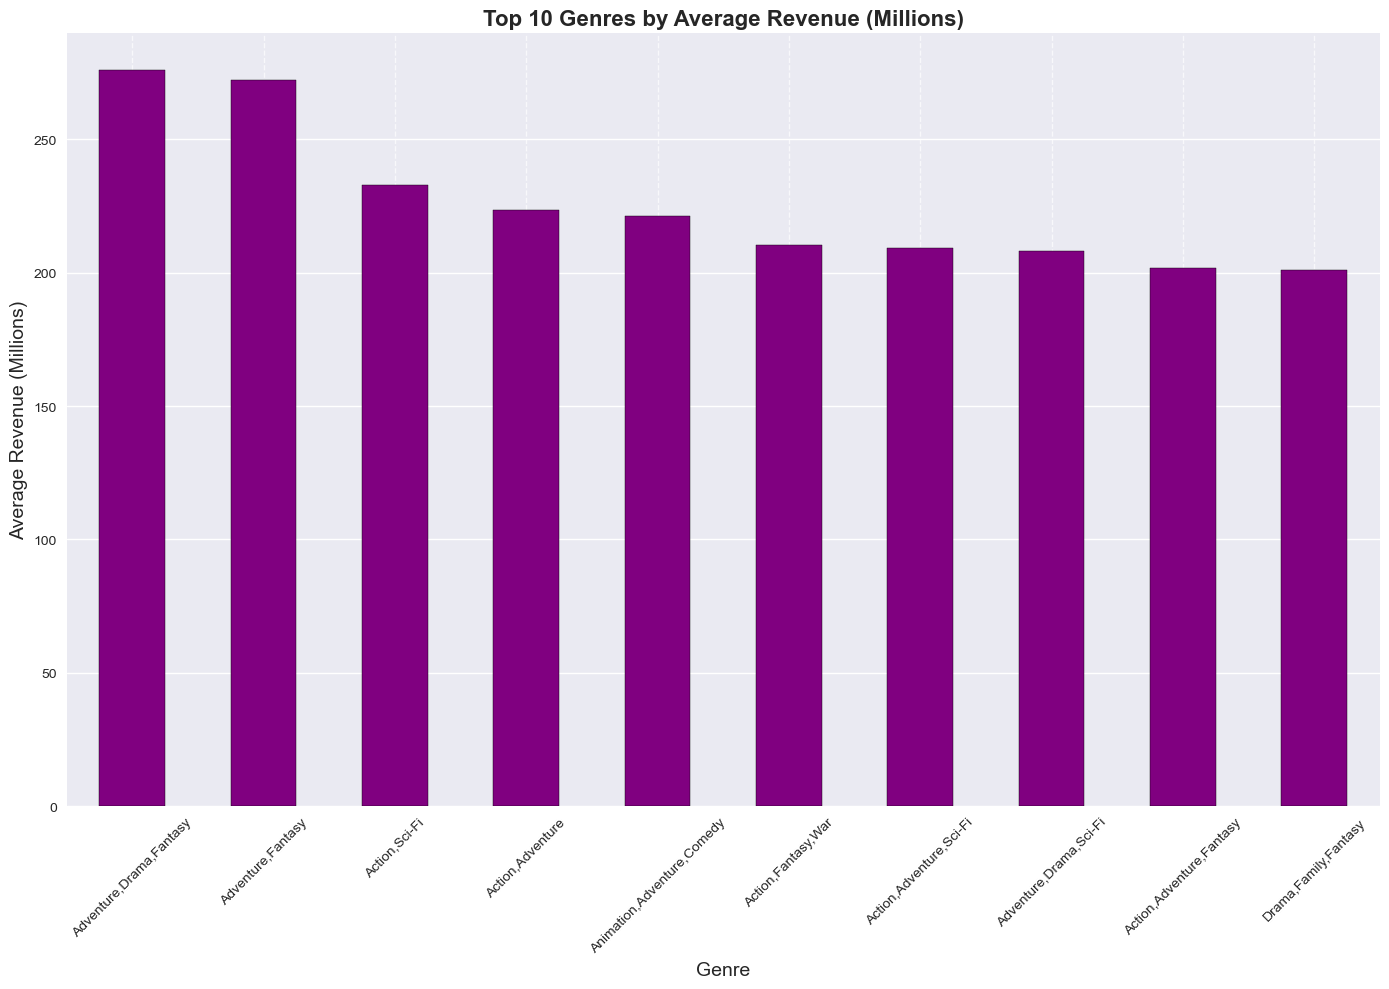

In [24]:
genre_revenue = df.groupby('Genre')['Revenue (Millions)'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 10))
genre_revenue.head(10).plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 10 Genres by Average Revenue (Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Average Revenue (Millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary

This analysis provides insights into:
- Correlations between movie attributes
- Distributions of key metrics
- Trends in revenue over time
- Genre performance
